Use the famous boston dataset and find out if there is multicollinearity or not. If there is multicollinearity try to remove it with help of steps taught in the session.

In [ ]:
# Link - https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , root_mean_squared_error , accuracy_score , r2_score

In [2]:
raw_df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

In [3]:
raw_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [21]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


#### OLS Method -> To check the accuracy score and various metrics and checking if multicollinerity exists

In [20]:
X = raw_df.drop('medv' , axis=1)
y = raw_df['medv']

# ----------------Shape of newly formed df and Series --------------------

print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)

In [23]:
# Standardize the features
from sklearn.preprocessing import StandardScaler
scal = StandardScaler()
cols = X_train.columns
X_train = scal.fit_transform(X_train)
X_test = scal.transform(X_test)

# -------- Convert back to Dfs ---------------

X_train = pd.DataFrame(X_train , columns =cols)
X_test = pd.DataFrame(X_test , columns =cols)

# ------- Let us check it --------------------

print(X_train.head())
print(X_test.head())


       crim        zn     indus  ...   ptratio         b     lstat
0  1.287702 -0.500320  1.033237  ...  0.845343 -0.074337  1.753505
1 -0.336384 -0.500320 -0.413160  ...  1.204741  0.430184 -0.561474
2 -0.403253  1.013271 -0.715218  ... -0.637176  0.065297 -0.651595
3  0.388230 -0.500320  1.033237  ...  0.845343 -3.868193  1.525387
4 -0.325282 -0.500320 -0.413160  ...  1.204741  0.379119 -0.165787

[5 rows x 13 columns]
       crim        zn     indus  ...   ptratio         b     lstat
0 -0.396809 -0.500320 -1.007111  ... -0.771951  0.428872 -0.481210
1 -0.400796  1.229499 -0.664391  ... -0.322703  0.444180 -1.257094
2 -0.395234 -0.500320  2.433163  ...  0.800418  0.369934  0.790338
3 -0.396825 -0.500320 -0.025421  ...  0.396095  0.378682 -0.976875
4  0.167084 -0.500320  1.033237  ...  0.845343  0.315043  0.677687

[5 rows x 13 columns]


In [24]:
# Adding the Constant column to the Training data 
import statsmodels.api as sm
X_train_w_cons = sm.add_constant(X_train)
print(X_train_w_cons.head(2))

   const      crim       zn     indus  ...       tax   ptratio         b     lstat
0    1.0  1.287702 -0.50032  1.033237  ...  1.578434  0.845343 -0.074337  1.753505
1    1.0 -0.336384 -0.50032 -0.413160  ... -0.584648  1.204741  0.430184 -0.561474

[2 rows x 14 columns]


In [29]:
y_train = y_train.reset_index(drop=True)

In [30]:
# Let us fit the OLS Method
model_OLS = sm.OLS(y_train , X_train_w_cons).fit()
print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     90.43
Date:                Tue, 12 May 2026   Prob (F-statistic):          6.21e-109
Time:                        10:51:16   Log-Likelihood:                -1194.3
No. Observations:                 404   AIC:                             2417.
Df Residuals:                     390   BIC:                             2473.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.7965      0.236     96.774      0.0

In [32]:
lr = LinearRegression()
model = lr.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [34]:
print(r2_score(y_test , y_pred))

0.668759493535632


### Method 1. Correlation Matrix

In [4]:
corr_matrix = raw_df.corr()

<Axes: >

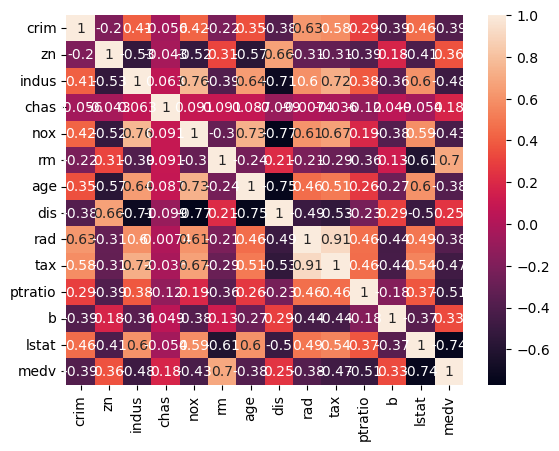

In [5]:
import seaborn as sns
sns.heatmap(corr_matrix , annot=True)

In [6]:
corr_matrix

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


In [39]:
cols = []
for i in range(corr_matrix.shape[1]):
    for j in range(i+1 , corr_matrix.shape[1]):
        corr_value = corr_matrix.iloc[i,j]
        if corr_value>0.8 or corr_value<-.8:
            cols.append(corr_matrix.columns[j])


In [40]:
print(set(cols))

{'tax'}


In [36]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     404 non-null    float64
 1   zn       404 non-null    float64
 2   indus    404 non-null    float64
 3   chas     404 non-null    float64
 4   nox      404 non-null    float64
 5   rm       404 non-null    float64
 6   age      404 non-null    float64
 7   dis      404 non-null    float64
 8   rad      404 non-null    float64
 9   tax      404 non-null    float64
 10  ptratio  404 non-null    float64
 11  b        404 non-null    float64
 12  lstat    404 non-null    float64
dtypes: float64(13)
memory usage: 41.2 KB


#### So we see that there is only tax column which has high correlation value >0.8 with some other column -> so we will remove it

### Method 2. VIF

In [47]:
# Let us check it using Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

vif_df = pd.DataFrame(vif , index = X_train.columns)

In [48]:
print(vif_df)

                0
crim     1.713187
zn       2.465631
indus    3.877855
chas     1.096674
nox      4.469150
rm       1.947809
age      2.989948
dis      4.168578
rad      7.658316
tax      8.943301
ptratio  1.851448
b        1.325121
lstat    2.818045


`So we see that Column "rad" and "tax" has VIF > 5 thus, they show signs of high multicollinearity`

### Method 3. Condtion Number

`From OLS Method we found Cond. No. = 9.74 which shows Multicollinearity but it is Not Severe`

#### Let us just fix those Columns and then Check Cond. No. again to see if the Fitting improved 


`Let us use Mean of rad and tax and then make it one column`

**Let us make a column named Prime_loc using Mean of Rad and Tax since rad signifies if property is near the highway and tax signify the amount of property tax to be given. So if the property is near highway, it is obvious that it would cost us more Tax**

In [51]:
X_train['prime_loc'] = (X_train['rad']+X_train['tax'])/2
X_test['prime_loc'] = (X_test['rad']+X_test['tax'])/2

X_train_remove_cols = X_train.drop(columns=['rad','tax'])
X_test_remove_cols = X_test.drop(columns=['rad','tax'])

In [53]:
X_train_remove_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   crim       404 non-null    float64
 1   zn         404 non-null    float64
 2   indus      404 non-null    float64
 3   chas       404 non-null    float64
 4   nox        404 non-null    float64
 5   rm         404 non-null    float64
 6   age        404 non-null    float64
 7   dis        404 non-null    float64
 8   ptratio    404 non-null    float64
 9   b          404 non-null    float64
 10  lstat      404 non-null    float64
 11  prime_loc  404 non-null    float64
dtypes: float64(12)
memory usage: 38.0 KB


In [54]:
# Let us fit the OLS Method
X_train_remove_cols_w_cons = sm.add_constant(X_train_remove_cols)
model_OLS_remove_cols = sm.OLS(y_train , X_train_remove_cols_w_cons).fit()
print(model_OLS_remove_cols.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     95.01
Date:                Tue, 12 May 2026   Prob (F-statistic):          7.50e-108
Time:                        11:34:56   Log-Likelihood:                -1199.3
No. Observations:                 404   AIC:                             2425.
Df Residuals:                     391   BIC:                             2477.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.7965      0.238     95.704      0.0

In [55]:
# Let us check the Cond. No. of the matrix
cond_no = np.linalg.cond(X_train_remove_cols)
print(cond_no)

5.919885528523576


In [ ]:
# Thus we dropped the Cond. Number form 7.9 to 5.92 which is great but we should deal with this prime_loc column since before this rad was highly significant
# but now prime_col has become insignificant


***Scaling made the averaging numerically valid, but it was still statistically wrong — because equal-weight averaging ignores the unequal predictive contributions that OLS had already quantified for you. The moment you saw rad significant and tax not, the answer was to drop tax.***

### We should have dropped the Tax column only and not use the new col all together. Let us do that and then find the OLS summary again

In [56]:
X_train_w_cons_rem_tax = X_train_w_cons.drop('tax' , axis=1)
X_test_rem_tax = X_test.drop('tax' , axis = 1)

In [58]:
X_train_w_cons_rem_tax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   const    404 non-null    float64
 1   crim     404 non-null    float64
 2   zn       404 non-null    float64
 3   indus    404 non-null    float64
 4   chas     404 non-null    float64
 5   nox      404 non-null    float64
 6   rm       404 non-null    float64
 7   age      404 non-null    float64
 8   dis      404 non-null    float64
 9   rad      404 non-null    float64
 10  ptratio  404 non-null    float64
 11  b        404 non-null    float64
 12  lstat    404 non-null    float64
dtypes: float64(13)
memory usage: 41.2 KB


In [59]:
# Let us now fit the model again
model_OLS_remove_tax = sm.OLS(y_train , X_train_w_cons_rem_tax).fit()
print(model_OLS_remove_tax.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     96.14
Date:                Tue, 12 May 2026   Prob (F-statistic):          1.36e-108
Time:                        11:54:20   Log-Likelihood:                -1197.6
No. Observations:                 404   AIC:                             2421.
Df Residuals:                     391   BIC:                             2473.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.7965      0.237     96.126      0.0

### We see that columns "zn" , "indus", "age" are insignificant so let us drop them and then check the summary

In [60]:
X_train_w_cons = X_train_w_cons.drop(["zn" , "indus", "age","tax"] , axis = 1)

In [61]:
X_test_dropped_insig = X_test.drop(["zn" , "indus", "age","tax"] , axis = 1)

In [63]:
model_dropped_insig = sm.OLS(y_train , X_train_w_cons).fit()
print(model_dropped_insig.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     128.3
Date:                Tue, 12 May 2026   Prob (F-statistic):          2.70e-111
Time:                        12:34:11   Log-Likelihood:                -1198.6
No. Observations:                 404   AIC:                             2417.
Df Residuals:                     394   BIC:                             2457.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.7965      0.237     96.250      0.0

`Clearly we have reduced Condition Number below 5 now, which is great!! Also now our features are all significant and F-stats = 128 which means features are highly significant for our target column`